# **ENVIRONMENT SETUP**

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings('ignore') 

import os, random, warnings, math, json, joblib
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
@dataclass
class TrainConfig:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 4
    pin_memory: bool = True

    batch_size_student: int = 8192
    batch_size_eval: int = 16384

    student_lr: float = 1e-3
    weight_decay: float = 3e-4
    max_epochs_student: int = 20
    patience: int = 5
    grad_clip: float = 1.0

    distill_alpha: float = 0.5
    distill_temperature: float = 4.0

    calibration_max_iter: int = 200
    routing_threshold_grid: int = 60

    student_hidden_dims: Tuple[int, ...] = (128, 64)
    student_dropout: float = 0.15

    # CatBoost teacher
    catboost_iterations: int = 800
    catboost_learning_rate: float = 0.03
    catboost_depth: int = 8
    catboost_l2_leaf_reg: float = 3.0
    catboost_border_count: int = 128
    catboost_task_type: str = "CPU"   # switch to "GPU" only if CatBoost GPU is configured
    catboost_od_wait: int = 50

    work_dir: str = "."
    teacher_ckpt: str = "teacher_catboost.cbm"
    student_ckpt: str = "student_mlp_best.pt"
    temp_ckpt: str = "student_temperature.joblib"
    threshold_ckpt: str = "routing_threshold.joblib"

# **Utilities**

In [3]:
def to_tensor(x: np.ndarray, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    return torch.as_tensor(x, dtype=dtype)

def make_loader(
    x: np.ndarray,
    y: Optional[np.ndarray] = None,
    batch_size: int = 4096,
    shuffle: bool = False,
    num_workers: int = 0,
    pin_memory: bool = True,
) -> DataLoader:
    x_t = to_tensor(x, torch.float32)
    if y is None:
        ds = TensorDataset(x_t)
    else:
        y_t = to_tensor(y, torch.long)
        ds = TensorDataset(x_t, y_t)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=(num_workers > 0),
    )

@torch.no_grad()
def accuracy_from_probs(probs: np.ndarray, y_true: np.ndarray) -> float:
    y_pred = probs.argmax(axis=1)
    return accuracy_score(y_true, y_pred)

@torch.no_grad()
def macro_f1_from_probs(probs: np.ndarray, y_true: np.ndarray) -> float:
    y_pred = probs.argmax(axis=1)
    return f1_score(y_true, y_pred, average="macro")

@torch.no_grad()
def evaluate_probs(probs: np.ndarray, y_true: np.ndarray, title: str = "") -> Dict[str, float]:
    y_pred = probs.argmax(axis=1)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average="macro")
    if title:
        print(f"{title} accuracy: {acc:.6f} | macro-F1: {mf1:.6f}")
    return {"accuracy": acc, "macro_f1": mf1}

# **Data Loading**

In [4]:
import json
import joblib
# Load data (as in the prompt)
BASE_PATH = "/kaggle/input/notebooks/yacermeftah/cicids-dataset-processing/cicids2017_processed"
with open(f"{BASE_PATH}/manifest.json") as f:
    manifest = json.load(f)

train_df = pd.read_parquet(f"{BASE_PATH}/data/train_processed.parquet")
test_df  = pd.read_parquet(f"{BASE_PATH}/data/test_processed.parquet")

In [5]:
X_train_raw = train_df.drop(columns=["LabelEncoded"])
y_train = train_df["LabelEncoded"].values

X_test_raw = test_df.drop(columns=["LabelEncoded"])
y_test = test_df["LabelEncoded"].values

In [6]:
scaler = joblib.load(f"{BASE_PATH}/artifacts/scaler.joblib")
X_train_scaled = scaler.transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

In [7]:
Label_Encoder = joblib.load(f"{BASE_PATH}/artifacts/label_encoder.joblib")

with open(f"{BASE_PATH}/artifacts//preprocess_settings.json") as f:
    settings = json.load(f)

In [8]:
feature_names = settings["feature_selection"]["selected_features"]
labels = list(settings["label_mapping"].keys())

In [9]:
# Train/validation split (multi‑class, stratified)
SEED = 42
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)
    
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (1480781, 34), Val: (370196, 34)


# **Models**

In [10]:
class CatBoostTeacherWrapper:
    def __init__(
        self,
        n_classes: int,
        iterations: int = 800,
        learning_rate: float = 0.03,
        depth: int = 8,
        l2_leaf_reg: float = 3.0,
        border_count: int = 128,
        task_type: str = "CPU",
        od_wait: int = 50,
        seed: int = 42,
        class_weights: Optional[List[float]] = None,
    ):
        self.n_classes = n_classes
        self.model = CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="MultiClass",
            iterations=iterations,
            learning_rate=learning_rate,
            depth=depth,
            l2_leaf_reg=l2_leaf_reg,
            border_count=border_count,
            random_seed=seed,
            task_type=task_type,
            od_type="Iter",
            od_wait=od_wait,
            use_best_model=True,
            verbose=100,
            class_weights=class_weights,
        )

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: Optional[np.ndarray] = None,
        y_val: Optional[np.ndarray] = None,
    ) -> "CatBoostTeacherWrapper":
        fit_kwargs = {}
        if X_val is not None and y_val is not None:
            fit_kwargs["eval_set"] = (X_val, y_val)
        self.model.fit(X_train, y_train, **fit_kwargs)
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        probs = self.model.predict_proba(X)
        return np.asarray(probs, dtype=np.float32)

    def save(self, path: str) -> None:
        self.model.save_model(path)

In [11]:
class ShallowMLP(nn.Module):
    def __init__(self, in_dim: int, n_classes: int, hidden_dims: Tuple[int, ...] = (128, 64), dropout: float = 0.15):
        super().__init__()
        layers: List[nn.Module] = []
        prev = in_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [12]:
class TemperatureScaler(nn.Module):
    """Single-parameter temperature scaling for multiclass calibration."""

    def __init__(self, init_temp: float = 1.0):
        super().__init__()
        self.log_temp = nn.Parameter(torch.log(torch.tensor(float(init_temp))))

    @property
    def temperature(self) -> torch.Tensor:
        return torch.exp(self.log_temp).clamp(min=1e-3, max=100.0)

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature

    def fit(self, logits: torch.Tensor, targets: torch.Tensor, max_iter: int = 200) -> "TemperatureScaler":
        self.train()
        opt = torch.optim.LBFGS([self.log_temp], lr=0.1, max_iter=max_iter, line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(self.forward(logits), targets)
            loss.backward()
            return loss

        opt.step(closure)
        self.eval()
        return self

# **loses**

In [13]:
def distillation_loss(
    student_logits: torch.Tensor,
    teacher_probs: torch.Tensor,
    targets: torch.Tensor,
    alpha: float = 0.5,
    temperature: float = 4.0,
) -> torch.Tensor:
    hard = F.cross_entropy(student_logits, targets)

    teacher_probs = teacher_probs.clamp_min(1e-8)
    teacher_probs = teacher_probs / teacher_probs.sum(dim=-1, keepdim=True)

    soft = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=-1),
        teacher_probs,
        reduction="batchmean",
    ) * (temperature ** 2)

    return alpha * hard + (1.0 - alpha) * soft

# **Training / inference loops**

In [14]:
def predict_teacher_probs(
    teacher: CatBoostTeacherWrapper,
    x: np.ndarray,
    device: Optional[str] = None,
    batch_size: Optional[int] = None,
) -> np.ndarray:
    return teacher.predict_proba(x)

In [15]:
def train_student_distilled(
    student: nn.Module,
    teacher: CatBoostTeacherWrapper,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    cfg: TrainConfig,
    class_weights: Optional[np.ndarray] = None,
) -> nn.Module:
    device = cfg.device
    student = student.to(device)

    optimizer = torch.optim.AdamW(student.parameters(), lr=cfg.student_lr, weight_decay=cfg.weight_decay)
    scaler = GradScaler(enabled=(device.startswith("cuda")))

    if class_weights is not None:
        cw = torch.as_tensor(class_weights, dtype=torch.float32, device=device)
    else:
        cw = None

    # Precompute teacher probabilities once
    teacher_probs_train = torch.as_tensor(
        predict_teacher_probs(teacher, x_train),
        dtype=torch.float32
    )

    idx_train = torch.arange(len(x_train), dtype=torch.long)
    train_ds = TensorDataset(
        to_tensor(x_train, torch.float32),
        to_tensor(y_train, torch.long),
        idx_train,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size_student,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        drop_last=False,
        persistent_workers=(cfg.num_workers > 0),
    )

    val_loader = make_loader(
        x_val,
        y_val,
        batch_size=cfg.batch_size_eval,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
    )

    best_acc = -1.0
    best_state = None
    patience_left = cfg.patience

    for epoch in range(1, cfg.max_epochs_student + 1):
        student.train()
        running = 0.0
        n_seen = 0

        for xb, yb, idx in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            t_probs = teacher_probs_train[idx].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=(device.startswith("cuda"))):
                student_logits = student(xb)

                if cw is None:
                    hard = F.cross_entropy(student_logits, yb)
                else:
                    hard = F.cross_entropy(student_logits, yb, weight=cw)

                soft = distillation_loss(
                    student_logits=student_logits,
                    teacher_probs=t_probs,
                    targets=yb,
                    alpha=cfg.distill_alpha,
                    temperature=cfg.distill_temperature,
                )
                loss = 0.5 * hard + 0.5 * soft

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if cfg.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(student.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            running += float(loss.item()) * xb.size(0)
            n_seen += xb.size(0)

        student.eval()
        probs_all = []
        y_all = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                logits = student(xb)
                probs_all.append(torch.softmax(logits, dim=-1).cpu())
                y_all.append(yb)

        val_probs = torch.cat(probs_all, dim=0).numpy()
        y_val_cat = torch.cat(y_all, dim=0).numpy()
        val_acc = accuracy_score(y_val_cat, val_probs.argmax(axis=1))

        print(f"[Student][Epoch {epoch:02d}] train_loss={running / max(n_seen, 1):.6f} val_acc={val_acc:.6f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}
            patience_left = cfg.patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Student early stopping triggered.")
                break

    if best_state is not None:
        student.load_state_dict(best_state)
    return student

In [16]:
@torch.no_grad()
def collect_student_logits(
    student: nn.Module,
    x: np.ndarray,
    device: str,
    batch_size: int,
    num_workers: int = 0,
    pin_memory: bool = True,
) -> torch.Tensor:
    student.eval()
    loader = make_loader(x, None, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    outs = []
    for (xb,) in loader:
        xb = xb.to(device, non_blocking=True)
        outs.append(student(xb).cpu())
    return torch.cat(outs, dim=0)


@torch.no_grad()
def predict_student_probs(
    student: nn.Module,
    x: np.ndarray,
    device: str,
    batch_size: int,
    temperature: float = 1.0,
) -> np.ndarray:
    student.eval()
    loader = make_loader(x, None, batch_size=batch_size, shuffle=False)
    probs_all = []
    for (xb,) in loader:
        xb = xb.to(device, non_blocking=True)
        logits = student(xb) / temperature
        probs_all.append(torch.softmax(logits, dim=-1).cpu())
    return torch.cat(probs_all, dim=0).numpy()

# **Calibration + routing**

In [17]:
def fit_student_temperature(
    student: nn.Module,
    x_val: np.ndarray,
    y_val: np.ndarray,
    device: str,
    batch_size: int,
    max_iter: int = 200,
) -> TemperatureScaler:
    student.eval()
    logits = collect_student_logits(student, x_val, device=device, batch_size=batch_size)
    targets = torch.as_tensor(y_val, dtype=torch.long)
    scaler = TemperatureScaler(init_temp=1.0)
    scaler.fit(logits, targets, max_iter=max_iter)
    return scaler


@torch.no_grad()
def student_confidence_with_temperature(
    student: nn.Module,
    x: np.ndarray,
    device: str,
    batch_size: int,
    temperature: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probs, confidence=max_prob) for calibrated student."""
    probs = predict_student_probs(student, x, device=device, batch_size=batch_size, temperature=temperature)
    conf = probs.max(axis=1)
    return probs, conf

In [18]:
def tune_routing_threshold(
    student: nn.Module,
    teacher: nn.Module,
    x_val: np.ndarray,
    y_val: np.ndarray,
    device: str,
    batch_size: int,
    temperature: float,
    num_grid: int = 60,
) -> Dict[str, float]:
    
    s_probs = predict_student_probs(student, x_val, device=device, batch_size=batch_size, temperature=temperature)
    t_probs = predict_teacher_probs(teacher, x_val, device=device, batch_size=batch_size)
    s_conf = s_probs.max(axis=1)
    s_pred = s_probs.argmax(axis=1)
    t_pred = t_probs.argmax(axis=1)

    lo, hi = float(np.quantile(s_conf, 0.01)), float(np.quantile(s_conf, 0.99))
    grid = np.linspace(max(0.1, lo), min(0.999, hi), num_grid)

    best = {
        "threshold": 0.5,
        "accuracy": -1.0,
        "teacher_usage": 1.0,
        "macro_f1": -1.0,
    }

    for thr in grid:
        use_student = s_conf >= thr
        routed_pred = np.where(use_student, s_pred, t_pred)
        acc = accuracy_score(y_val, routed_pred)
        mf1 = f1_score(y_val, routed_pred, average="macro")
        teacher_usage = float((~use_student).mean())

        improved = (acc > best["accuracy"]) or (
            math.isclose(acc, best["accuracy"], rel_tol=0.0, abs_tol=1e-12) and teacher_usage < best["teacher_usage"]
        )
        if improved:
            best = {
                "threshold": float(thr),
                "accuracy": float(acc),
                "teacher_usage": float(teacher_usage),
                "macro_f1": float(mf1),
            }

    print(
        f"[Routing] best_threshold={best['threshold']:.4f} | routed_val_acc={best['accuracy']:.6f} | "
        f"teacher_usage={best['teacher_usage']:.4%} | routed_val_macro_f1={best['macro_f1']:.6f}"
    )
    return best


@torch.no_grad()
def routed_predict(
    student: nn.Module,
    teacher: nn.Module,
    x: np.ndarray,
    device: str,
    batch_size: int,
    temperature: float,
    threshold: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (final_probs, student_confidence, teacher_mask)."""
    s_probs = predict_student_probs(student, x, device=device, batch_size=batch_size, temperature=temperature)
    t_probs = predict_teacher_probs(teacher, x, device=device, batch_size=batch_size)
    s_conf = s_probs.max(axis=1)
    teacher_mask = s_conf < threshold
    final_probs = np.where(teacher_mask[:, None], t_probs, s_probs)
    return final_probs, s_conf, teacher_mask

# **Main execution**

In [19]:
out_dir = "/kaggle/working/"
class_weights = settings["class_weights"]
cfg=TrainConfig(work_dir="/kaggle/working/tdr_ids")
os.makedirs(cfg.work_dir, exist_ok=True)

paths = {}

teacher_path = os.path.join(out_dir, "teacher_state_dict.pt")
student_path = os.path.join(out_dir, "student_state_dict.pt")
paths["teacher_state_dict"] = teacher_path
paths["student_state_dict"] = student_path

routing_path = os.path.join(out_dir, "routing_config.joblib")
paths["routing_config"] = routing_path

meta_path = os.path.join(out_dir, "metadata.json")
paths["metadata"] = meta_path

In [20]:
n_features = X_train.shape[1]
n_classes = int(len(np.unique(y_train)))
device = cfg.device
print(f"Device: {device} | Features: {n_features} | Classes: {n_classes}")

cw_vec = None
if class_weights is not None:
    cw_vec = np.array([class_weights[name] for name in labels], dtype=np.float32)
    print("Class weights vector:", cw_vec)

Device: cuda | Features: 34 | Classes: 9
Class weights vector: [ 0.13002044  2.0082228  24.992601    1.4873343  49.17841    47.740044
 43.34333    46.040768   79.86956   ]


In [21]:
# 1) Teacher: CatBoost
teacher = CatBoostTeacherWrapper(
    n_classes=n_classes,
    iterations=cfg.catboost_iterations,
    learning_rate=cfg.catboost_learning_rate,
    depth=cfg.catboost_depth,
    l2_leaf_reg=cfg.catboost_l2_leaf_reg,
    border_count=cfg.catboost_border_count,
    task_type=cfg.catboost_task_type,
    od_wait=cfg.catboost_od_wait,
    seed=cfg.seed,
    class_weights=cw_vec.tolist() if cw_vec is not None else None,
)

teacher = teacher.fit(X_train, y_train, X_val=X_val, y_val=y_val)

0:	learn: 2.0061035	test: 2.0065383	best: 2.0065383 (0)	total: 3.23s	remaining: 42m 58s
100:	learn: 0.1316935	test: 0.1334392	best: 0.1334392 (100)	total: 5m 16s	remaining: 36m 31s
200:	learn: 0.0507977	test: 0.0541718	best: 0.0541718 (200)	total: 10m 29s	remaining: 31m 14s
300:	learn: 0.0298300	test: 0.0350713	best: 0.0350713 (300)	total: 15m 41s	remaining: 26m
400:	learn: 0.0209804	test: 0.0277427	best: 0.0277427 (400)	total: 20m 52s	remaining: 20m 46s
500:	learn: 0.0159760	test: 0.0241514	best: 0.0241514 (500)	total: 26m 4s	remaining: 15m 33s
600:	learn: 0.0130186	test: 0.0223272	best: 0.0223272 (600)	total: 31m 15s	remaining: 10m 21s
700:	learn: 0.0109503	test: 0.0211609	best: 0.0211609 (700)	total: 36m 26s	remaining: 5m 8s
799:	learn: 0.0094261	test: 0.0204026	best: 0.0204026 (799)	total: 41m 37s	remaining: 0us

bestTest = 0.02040261466
bestIteration = 799



In [22]:
teacher_path = os.path.join(cfg.work_dir, cfg.teacher_ckpt)
teacher.save(teacher_path)
print(f"Saved teacher to: {teacher_path}")

Saved teacher to: /kaggle/working/tdr_ids/teacher_catboost.cbm


In [23]:
teacher_val_probs = predict_teacher_probs(teacher, X_val)
teacher_test_probs = predict_teacher_probs(teacher, X_test)
print("Teacher validation:")
evaluate_probs(teacher_val_probs, y_val, title="Teacher/Val")
print("Teacher test:")
evaluate_probs(teacher_test_probs, y_test, title="Teacher/Test")

Teacher validation:
Teacher/Val accuracy: 0.995600 | macro-F1: 0.936722
Teacher test:
Teacher/Test accuracy: 0.995490 | macro-F1: 0.936430


{'accuracy': 0.995489956671601, 'macro_f1': 0.93643049332702}

In [24]:
# 2) Student
student = ShallowMLP(
    in_dim=n_features,
    n_classes=n_classes,
    hidden_dims=cfg.student_hidden_dims,
    dropout=cfg.student_dropout,
)

student = train_student_distilled(
    student,
    teacher,
    X_train,
    y_train,
    X_val,
    y_val,
    cfg,
    class_weights=cw_vec,
)

student_path = os.path.join(cfg.work_dir, cfg.student_ckpt)
torch.save(student.state_dict(), student_path)
print(f"Saved student to: {student_path}")

[Student][Epoch 01] train_loss=4.907623 val_acc=0.978565
[Student][Epoch 02] train_loss=0.969252 val_acc=0.980635
[Student][Epoch 03] train_loss=0.614567 val_acc=0.981205
[Student][Epoch 04] train_loss=0.527632 val_acc=0.983036
[Student][Epoch 05] train_loss=0.486118 val_acc=0.981194
[Student][Epoch 06] train_loss=0.462405 val_acc=0.983584
[Student][Epoch 07] train_loss=0.448203 val_acc=0.983241
[Student][Epoch 08] train_loss=0.437628 val_acc=0.982328
[Student][Epoch 09] train_loss=0.427207 val_acc=0.984222
[Student][Epoch 10] train_loss=0.420971 val_acc=0.982669
[Student][Epoch 11] train_loss=0.417849 val_acc=0.982642
[Student][Epoch 12] train_loss=0.409036 val_acc=0.982815
[Student][Epoch 13] train_loss=0.404633 val_acc=0.982912
[Student][Epoch 14] train_loss=0.400608 val_acc=0.982771
Student early stopping triggered.
Saved student to: /kaggle/working/tdr_ids/student_mlp_best.pt


In [25]:
# Student before calibration
student_val_probs_raw = predict_student_probs(student, X_val, device=device, batch_size=cfg.batch_size_eval, temperature=1.0)
student_test_probs_raw = predict_student_probs(student, X_test, device=device, batch_size=cfg.batch_size_eval, temperature=1.0)
print("Student (uncalibrated) validation:")
evaluate_probs(student_val_probs_raw, y_val, title="Student/Val raw")
print("Student (uncalibrated) test:")
evaluate_probs(student_test_probs_raw, y_test, title="Student/Test raw")

Student (uncalibrated) validation:
Student/Val raw accuracy: 0.984222 | macro-F1: 0.839404
Student (uncalibrated) test:
Student/Test raw accuracy: 0.983594 | macro-F1: 0.834860


{'accuracy': 0.9835935558460923, 'macro_f1': 0.8348596537448564}

In [26]:
# 3) Temperature scaling
temp_scaler = fit_student_temperature(
    student,
    X_val,
    y_val,
    device=device,
    batch_size=cfg.batch_size_eval,
    max_iter=cfg.calibration_max_iter,
)
temperature = float(temp_scaler.temperature.item())
temp_path = os.path.join(cfg.work_dir, cfg.temp_ckpt)
joblib.dump({"temperature": temperature}, temp_path)
print(f"Learned student temperature: {temperature:.6f} | saved to: {temp_path}")

Learned student temperature: 2.079877 | saved to: /kaggle/working/tdr_ids/student_temperature.joblib


In [27]:
student_val_probs = predict_student_probs(student, X_val, device=device, batch_size=cfg.batch_size_eval, temperature=temperature)
student_test_probs = predict_student_probs(student, X_test, device=device, batch_size=cfg.batch_size_eval, temperature=temperature)
print("Student (calibrated) validation:")
evaluate_probs(student_val_probs, y_val, title="Student/Val calibrated")
print("Student (calibrated) test:")
evaluate_probs(student_test_probs, y_test, title="Student/Test calibrated")

Student (calibrated) validation:
Student/Val calibrated accuracy: 0.984222 | macro-F1: 0.839404
Student (calibrated) test:
Student/Test calibrated accuracy: 0.983594 | macro-F1: 0.834860


{'accuracy': 0.9835935558460923, 'macro_f1': 0.8348596537448564}

In [28]:
# 4) Routing threshold
routing = tune_routing_threshold(
    student,
    teacher,
    X_val,
    y_val,
    device=device,
    batch_size=cfg.batch_size_eval,
    temperature=temperature,
    num_grid=cfg.routing_threshold_grid,
)
threshold = routing["threshold"]
threshold_path = os.path.join(cfg.work_dir, cfg.threshold_ckpt)
joblib.dump(routing, threshold_path)
print(f"Saved routing config to: {threshold_path}")

[Routing] best_threshold=0.9662 | routed_val_acc=0.996299 | teacher_usage=9.3375% | routed_val_macro_f1=0.949214
Saved routing config to: /kaggle/working/tdr_ids/routing_threshold.joblib


In [29]:
# 5) Routed inference
routed_probs, student_conf, teacher_mask = routed_predict(
    student,
    teacher,
    X_test,
    device=device,
    batch_size=cfg.batch_size_eval,
    temperature=temperature,
    threshold=threshold,
)

routed_metrics = evaluate_probs(routed_probs, y_test, title="Routed/Test")
teacher_usage = float(teacher_mask.mean())
student_usage = 1.0 - teacher_usage
print(f"Routed test teacher usage: {teacher_usage:.4%} | student usage: {student_usage:.4%}")

Routed/Test accuracy: 0.996151 | macro-F1: 0.946932
Routed test teacher usage: 9.2641% | student usage: 90.7359%


In [30]:
print("\nClassification report (routed test):")
print(classification_report(y_test, routed_probs.argmax(axis=1), target_names=labels, digits=4))

print("Confusion matrix (routed test):")
print(confusion_matrix(y_test, routed_probs.argmax(axis=1)))


Classification report (routed test):
                  precision    recall  f1-score   support

          Benign     0.9995    0.9963    0.9979    395447
            DDoS     0.9970    0.9988    0.9979     25603
   DoS GoldenEye     0.9287    0.9942    0.9603      2057
        DoS Hulk     0.9894    0.9946    0.9920     34569
DoS Slowhttptest     0.8561    0.9952    0.9204      1046
   DoS slowloris     0.9631    0.9935    0.9781      1077
     FTP-Patator     0.9279    0.9983    0.9618      1186
           Other     0.6325    0.9409    0.7565      1116
     SSH-Patator     0.9199    0.9984    0.9576       644

        accuracy                         0.9962    462745
       macro avg     0.9127    0.9900    0.9469    462745
    weighted avg     0.9967    0.9962    0.9963    462745

Confusion matrix (routed test):
[[393978     77    114    367    169     39     92    557     54]
 [    32  25571      0      0      0      0      0      0      0]
 [    10      0   2045      0      2     

# **Evaluation**

In [31]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report,
)

**Helpers**

In [32]:
def set_plot_style() -> None:
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams["figure.figsize"] = (10, 6)
    plt.rcParams["axes.titleweight"] = "bold"
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["legend.frameon"] = True


def one_hot(y: np.ndarray, n_classes: int) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    out = np.zeros((len(y), n_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out


def expected_calibration_error(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 15,
) -> float:
    """
    Multiclass ECE using max-confidence binning.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    conf = y_prob.max(axis=1)
    pred = y_prob.argmax(axis=1)
    acc = (pred == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf >= lo) & (conf < hi)

        if not np.any(mask):
            continue

        bin_acc = acc[mask].mean()
        bin_conf = conf[mask].mean()
        ece += (mask.mean()) * abs(bin_acc - bin_conf)

    return float(ece)


def multiclass_brier_score(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """
    Multiclass Brier score = mean squared error over the full probability vector.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_oh = one_hot(y_true, y_prob.shape[1])
    return float(np.mean(np.sum((y_prob - y_oh) ** 2, axis=1)))


def top_label_calibration_error(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 15,
) -> float:
    """
    Alias for ECE on top-label confidence.
    """
    return expected_calibration_error(y_true, y_prob, n_bins=n_bins)


def compute_classification_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    labels: List[str],
    n_bins: int = 15,
) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = y_prob.argmax(axis=1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y_true, y_prob, labels=list(range(len(labels)))),
        "brier_score": multiclass_brier_score(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=n_bins),
    }
    return {k: float(v) for k, v in metrics.items()}


def build_metrics_frame(results: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    metric_order = [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
        "log_loss",
        "brier_score",
        "ece",
    ]
    cols = [c for c in metric_order if c in df.columns]
    return df[cols].sort_index()

**per-Block Evaluation**

In [33]:
def evaluate_probs(
    y_prob: np.ndarray,
    y_true: np.ndarray,
    labels: List[str],
    title: str = "Model",
    n_bins: int = 15,
    print_report: bool = True,
) -> Dict[str, float]:
    """
    Evaluate one probability output tensor against labels.
    """
    metrics = compute_classification_metrics(y_true, y_prob, labels=labels, n_bins=n_bins)
    y_pred = y_prob.argmax(axis=1)

    if print_report:
        print(f"\n[{title}]")
        for k, v in metrics.items():
            print(f"{k:>18s}: {v:.6f}")
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, target_names=labels, digits=4, zero_division=0))

    return metrics


def evaluate_confidence_routing(
    y_true: np.ndarray,
    student_probs: np.ndarray,
    teacher_probs: np.ndarray,
    threshold: float,
    labels: List[str],
    title: str = "Routed System",
    n_bins: int = 15,
    print_report: bool = True,
) -> Dict[str, float]:
    """
    Evaluate the final routed system from already computed student/teacher probabilities.
    """
    s_conf = student_probs.max(axis=1)
    use_teacher = s_conf < threshold
    final_probs = np.where(use_teacher[:, None], teacher_probs, student_probs)

    metrics = evaluate_probs(
        final_probs, y_true, labels=labels, title=title, n_bins=n_bins, print_report=print_report
    )
    metrics["teacher_usage"] = float(use_teacher.mean())
    metrics["student_usage"] = float(1.0 - use_teacher.mean())
    return metrics

**ploting**

In [34]:
def plot_metric_comparison(
    metrics_df: pd.DataFrame,
    save_path: Optional[str] = None,
    figsize: Tuple[int, int] = (14, 6),
) -> None:
    """
    Side-by-side bar plot for the main metrics.
    """
    set_plot_style()
    plot_df = metrics_df.reset_index(names="block")

    long_df = plot_df.melt(
        id_vars="block",
        value_vars=[c for c in plot_df.columns if c != "block"],
        var_name="metric",
        value_name="value",
    )

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=long_df, x="metric", y="value", hue="block", ax=ax)
    ax.set_title("Block-wise Performance Comparison")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Block", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

In [35]:
def plot_confusion_matrices(
    y_true: np.ndarray,
    probs_by_block: Dict[str, np.ndarray],
    labels: List[str],
    save_dir: Optional[str] = None,
    normalize: bool = True,
) -> None:
    """
    One confusion matrix per block.
    """
    set_plot_style()
    n_blocks = len(probs_by_block)
    fig, axes = plt.subplots(n_blocks, 1, figsize=(10, 5 * n_blocks))
    if n_blocks == 1:
        axes = [axes]

    for ax, (name, probs) in zip(axes, probs_by_block.items()):
        y_pred = probs.argmax(axis=1)
        cm = confusion_matrix(y_true, y_pred)

        if normalize:
            cm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1.0)

        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f" if normalize else "d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
            cbar=False,
        )
        ax.set_title(f"{name} Confusion Matrix" + (" (Normalized)" if normalize else ""))
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, "confusion_matrices.png"), dpi=200, bbox_inches="tight")
    plt.show()

In [36]:
def plot_calibration_curve(
    y_true: np.ndarray,
    probs_by_block: Dict[str, np.ndarray],
    n_bins: int = 15,
    save_path: Optional[str] = None,
) -> None:
    """
    Reliability diagram using top-label confidence.
    """
    set_plot_style()
    fig, ax = plt.subplots(figsize=(8, 8))

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for name, probs in probs_by_block.items():
        conf = probs.max(axis=1)
        pred = probs.argmax(axis=1)
        correct = (pred == y_true).astype(np.float32)

        bin_accs = []
        bin_confs = []
        bin_counts = []

        for i in range(n_bins):
            lo, hi = bin_edges[i], bin_edges[i + 1]
            if i == n_bins - 1:
                mask = (conf >= lo) & (conf <= hi)
            else:
                mask = (conf >= lo) & (conf < hi)

            if mask.sum() == 0:
                continue

            bin_accs.append(correct[mask].mean())
            bin_confs.append(conf[mask].mean())
            bin_counts.append(mask.mean())

        ax.plot(bin_confs, bin_accs, marker="o", linewidth=2, label=name)

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.set_title("Calibration / Reliability Diagram")
    ax.set_xlabel("Mean Confidence")
    ax.set_ylabel("Empirical Accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_confidence_distributions(
    probs_by_block: Dict[str, np.ndarray],
    save_path: Optional[str] = None,
) -> None:
    """
    Histogram of max predicted probability for each block.
    """
    set_plot_style()
    rows = []
    for name, probs in probs_by_block.items():
        conf = probs.max(axis=1)
        rows.append(pd.DataFrame({"block": name, "confidence": conf}))
    df = pd.concat(rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(data=df, x="confidence", hue="block", bins=30, stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title("Prediction Confidence Distribution")
    ax.set_xlabel("Max Probability")
    ax.set_ylabel("Density")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

**Full evaluation orchestrator**

In [37]:
@dataclass
class EvaluationArtifacts:
    metrics: pd.DataFrame
    probs: Dict[str, np.ndarray]
    routed_metrics: Dict[str, float]


def evaluate_system(
    teacher_test_probs: np.ndarray,
    student_test_probs_raw: np.ndarray,
    student_test_probs_calibrated: np.ndarray,
    routed_test_probs: np.ndarray,
    y_test: np.ndarray,
    labels: List[str],
    title_prefix: str = "Test",
    save_dir: Optional[str] = None,
    n_bins: int = 15,
) -> EvaluationArtifacts:
    """
    Evaluate all blocks independently and the routed system overall.
    """
    os.makedirs(save_dir, exist_ok=True) if save_dir else None

    block_probs = {
        f"Teacher/{title_prefix}": teacher_test_probs,
        f"Student Raw/{title_prefix}": student_test_probs_raw,
        f"Student Calibrated/{title_prefix}": student_test_probs_calibrated,
        f"Routed/{title_prefix}": routed_test_probs,
    }

    metrics = {}
    for block_name, probs in block_probs.items():
        metrics[block_name] = evaluate_probs(
            probs,
            y_test,
            labels=labels,
            title=block_name,
            n_bins=n_bins,
            print_report=True,
        )

    metrics_df = build_metrics_frame(metrics)
    print("\nBlock-wise summary:")
    print(metrics_df.round(6))

    # Save table if requested
    if save_dir:
        metrics_df.to_csv(os.path.join(save_dir, "block_metrics.csv"))

    # Plots
    plot_metric_comparison(
        metrics_df,
        save_path=os.path.join(save_dir, "metrics_comparison.png") if save_dir else None,
    )
    plot_confusion_matrices(
        y_test,
        block_probs,
        labels=labels,
        save_dir=save_dir,
        normalize=True,
    )
    plot_calibration_curve(
        y_test,
        block_probs,
        n_bins=n_bins,
        save_path=os.path.join(save_dir, "calibration_curve.png") if save_dir else None,
    )
    plot_confidence_distributions(
        block_probs,
        save_path=os.path.join(save_dir, "confidence_distribution.png") if save_dir else None,
    )

    return EvaluationArtifacts(
        metrics=metrics_df,
        probs=block_probs,
        routed_metrics=metrics[f"Routed/{title_prefix}"],
    )

In [38]:
def evaluate_routing_behavior(
    student_probs: np.ndarray,
    teacher_probs: np.ndarray,
    y_true: np.ndarray,
    threshold: float,
    labels: List[str],
    save_path: Optional[str] = None,
) -> pd.DataFrame:
    """
    Analyze how routing behaves over confidence bins.
    """
    set_plot_style()
    s_conf = student_probs.max(axis=1)
    s_pred = student_probs.argmax(axis=1)
    t_pred = teacher_probs.argmax(axis=1)
    use_teacher = s_conf < threshold
    final_pred = np.where(use_teacher, t_pred, s_pred)

    df = pd.DataFrame(
        {
            "student_confidence": s_conf,
            "use_teacher": use_teacher.astype(int),
            "correct": (final_pred == y_true).astype(int),
        }
    )

    bins = pd.cut(df["student_confidence"], bins=np.linspace(0, 1, 11), include_lowest=True)
    summary = (
        df.groupby(bins)
        .agg(
            n=("correct", "size"),
            teacher_usage=("use_teacher", "mean"),
            routed_accuracy=("correct", "mean"),
            avg_confidence=("student_confidence", "mean"),
        )
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=summary, x="avg_confidence", y="teacher_usage", marker="o", ax=ax1, label="Teacher usage")
    sns.lineplot(data=summary, x="avg_confidence", y="routed_accuracy", marker="o", ax=ax1, label="Routed accuracy")
    ax1.set_title("Routing Behavior by Student Confidence")
    ax1.set_xlabel("Average Student Confidence")
    ax1.set_ylabel("Rate")
    ax1.set_ylim(0, 1)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    return summary

In [39]:
student_test_probs_calibrated = predict_student_probs(
    student,
    X_test,
    device=cfg.device,
    batch_size=cfg.batch_size_eval,
    temperature=temperature,
)

**Teacher Evaluation**


[Teacher/Test]
          accuracy: 0.995490
 balanced_accuracy: 0.996079
          macro_f1: 0.936430
       weighted_f1: 0.995910
   macro_precision: 0.896550
      macro_recall: 0.996079
          log_loss: 0.021084
       brier_score: 0.008300
               ece: 0.007469

Classification report:
                  precision    recall  f1-score   support

          Benign     0.9999    0.9951    0.9975    395447
            DDoS     0.9974    0.9993    0.9984     25603
   DoS GoldenEye     0.9150    0.9990    0.9551      2057
        DoS Hulk     0.9908    0.9965    0.9937     34569
DoS Slowhttptest     0.8892    0.9971    0.9401      1046
   DoS slowloris     0.9477    0.9935    0.9701      1077
     FTP-Patator     0.9230    1.0000    0.9599      1186
           Other     0.4991    0.9857    0.6627      1116
     SSH-Patator     0.9069    0.9984    0.9505       644

        accuracy                         0.9955    462745
       macro avg     0.8966    0.9961    0.9364    462745
 

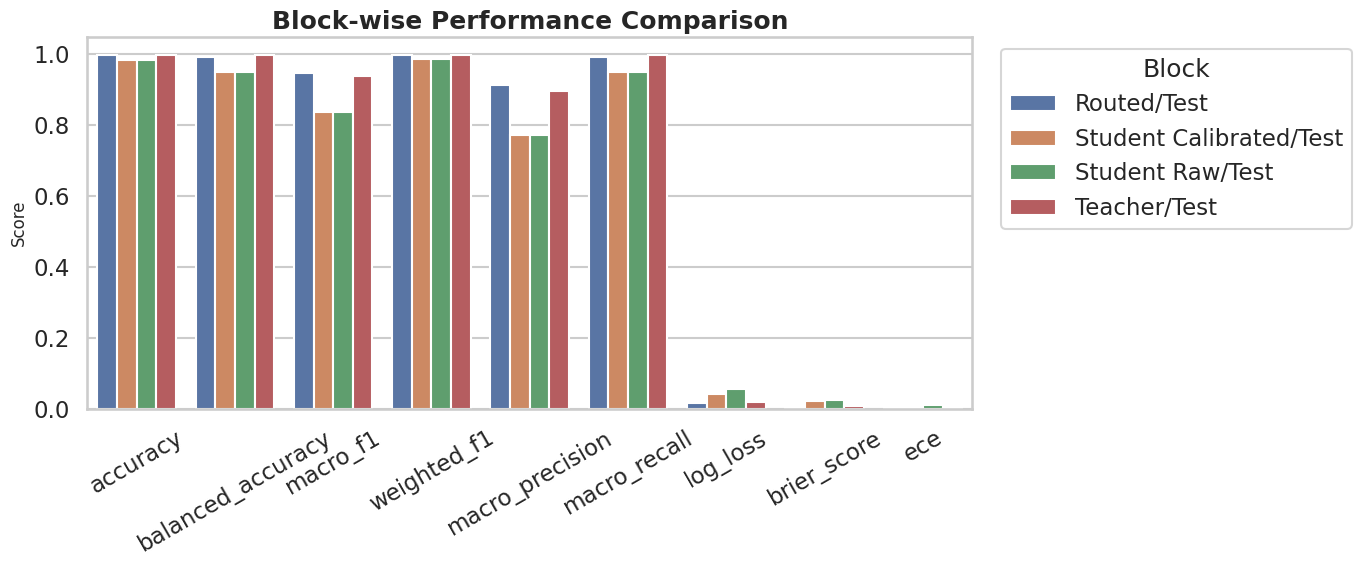

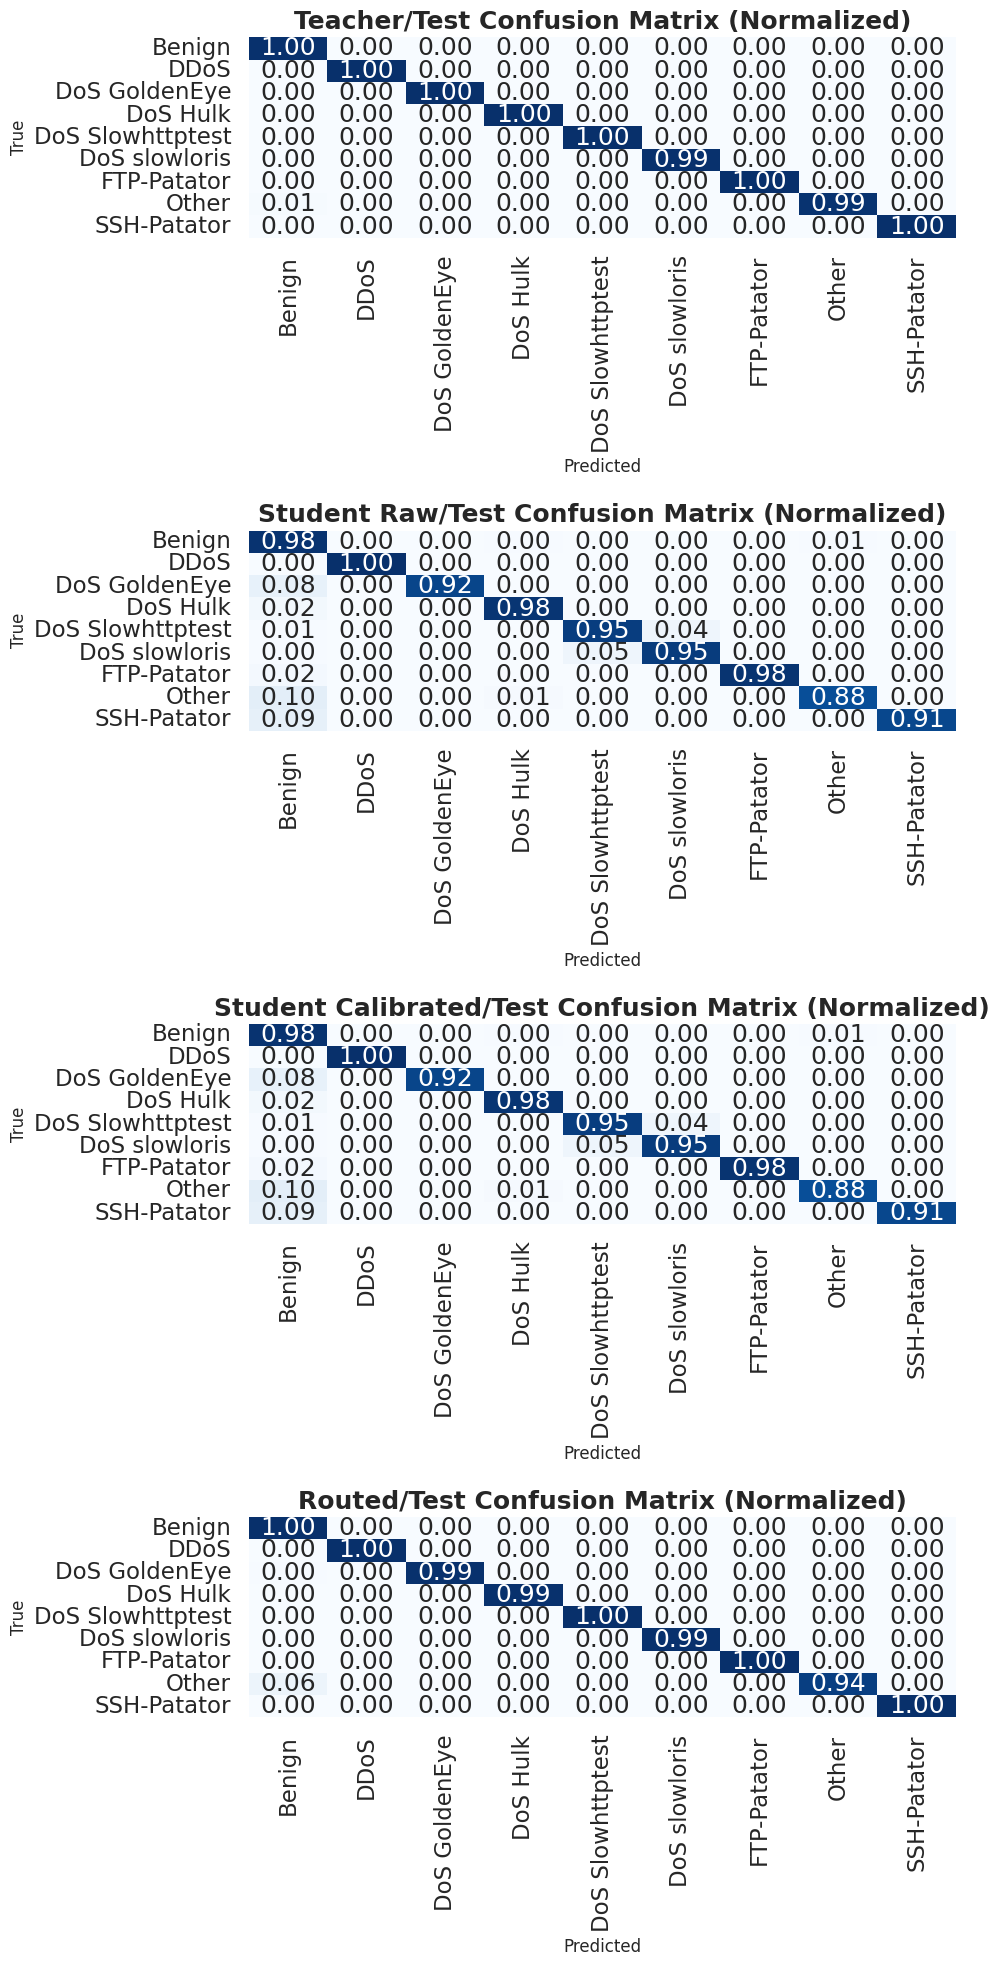

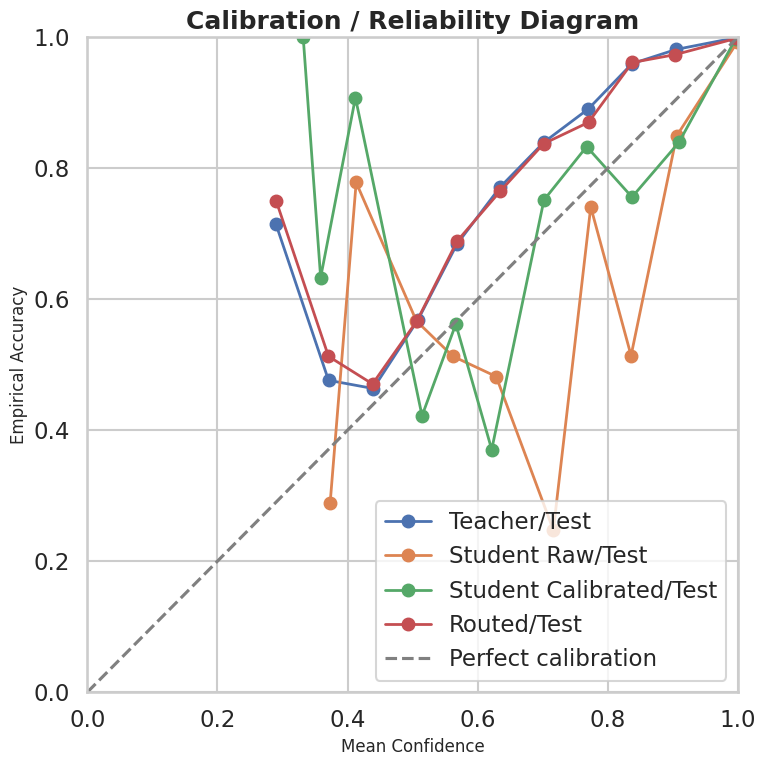

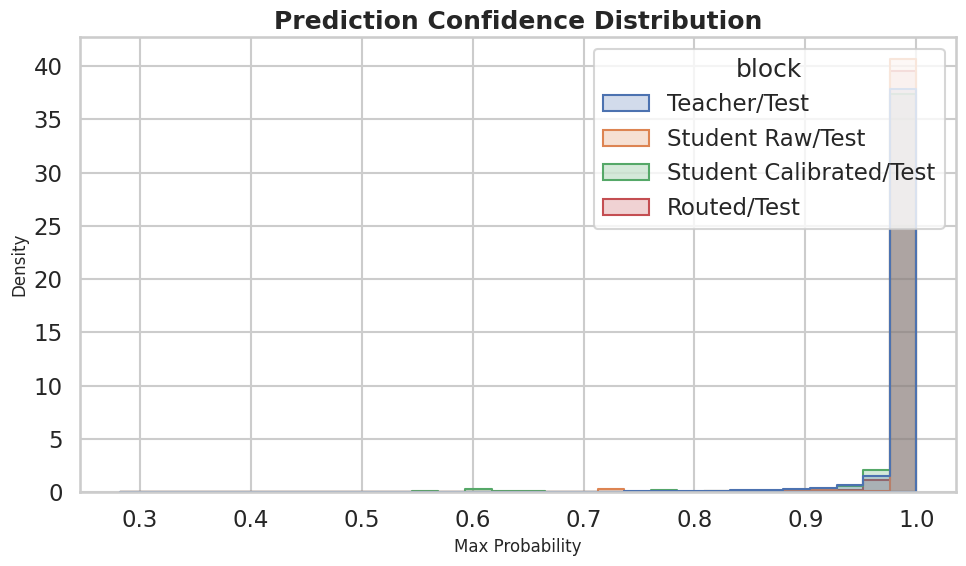

                         accuracy  balanced_accuracy  macro_f1  weighted_f1  \
Routed/Test              0.996151           0.990015  0.946932     0.996321   
Student Calibrated/Test  0.983594           0.949256  0.834860     0.985587   
Student Raw/Test         0.983594           0.949256  0.834860     0.985587   
Teacher/Test             0.995490           0.996079  0.936430     0.995910   

                         macro_precision  macro_recall  log_loss  brier_score  \
Routed/Test                     0.912670      0.990015  0.018076     0.007036   
Student Calibrated/Test         0.772524      0.949256  0.041393     0.022566   
Student Raw/Test                0.772524      0.949256  0.057634     0.025113   
Teacher/Test                    0.896550      0.996079  0.021084     0.008300   

                              ece  
Routed/Test              0.002768  
Student Calibrated/Test  0.005678  
Student Raw/Test         0.011215  
Teacher/Test             0.007469  


In [40]:
artifacts = evaluate_system(
    teacher_test_probs=teacher_test_probs,
    student_test_probs_raw=predict_student_probs(
        student, X_test, device=cfg.device, batch_size=cfg.batch_size_eval, temperature=1.0
    ),
    student_test_probs_calibrated=student_test_probs_calibrated,
    routed_test_probs=routed_probs,
    y_test=y_test,
    labels=labels,
    title_prefix="Test",
    save_dir="/kaggle/working/tdr_ids/eval",
    n_bins=15,
)

print(artifacts.metrics)

**Routing**

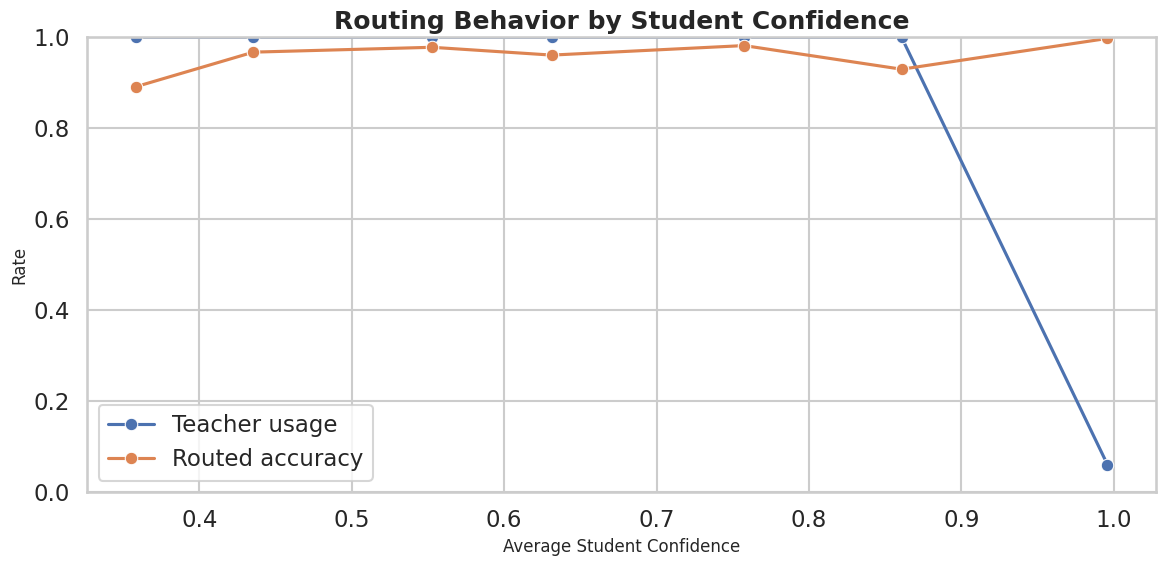

  student_confidence       n  teacher_usage  routed_accuracy  avg_confidence
0      (-0.001, 0.1]       0            NaN              NaN             NaN
1         (0.1, 0.2]       0            NaN              NaN             NaN
2         (0.2, 0.3]       0            NaN              NaN             NaN
3         (0.3, 0.4]     470       1.000000         0.891489        0.358384
4         (0.4, 0.5]     215       1.000000         0.967442        0.435430
5         (0.5, 0.6]    1874       1.000000         0.978122        0.552644
6         (0.6, 0.7]    5017       1.000000         0.960933        0.631133
7         (0.7, 0.8]    3255       1.000000         0.981874        0.757395
8         (0.8, 0.9]    4949       1.000000         0.929885        0.860713
9         (0.9, 1.0]  446965       0.060607         0.997584        0.995766


In [41]:
routing_summary = evaluate_routing_behavior(
    student_probs=student_test_probs_calibrated,
    teacher_probs=teacher_test_probs,
    y_true=y_test,
    threshold=threshold,
    labels=labels,
    save_path="/kaggle/working/tdr_ids/eval/routing_behavior.png",
)

print(routing_summary)